## Data Cleaning

### 1. Import necessary libraries
Import data manipulation and visualization libraries such as pandas, numpy, and matplotlib/seaborn.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

### 2. Load the Dataset
Read the `netflix_titles.csv` dataset into a pandas DataFrame.

In [2]:
df =pd.read_csv("data/netflix_titles.csv")

### 3. Check Dataset Info
Understand the structural outline of the dataset, columns, counts, and their primary data types.

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


### 4. Check for Null Values
Calculate the percentage of missing values in each column to prioritize our cleaning efforts.

In [4]:
print(df.isnull().mean()*100)

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64


### 5. Drop Missing Core Features
Drop rows with missing values specifically in `date_added`, `rating`, and `duration` as they are essential to analyze timelines and content length.

In [5]:
df.dropna(subset =['date_added','rating','duration'], inplace = True)

### 6. Correct Datetime Formats
Convert strings into robust pandas datetime objects and use them as the primary DataFrame index.

In [6]:
df['date_added'] = df['date_added'].apply(pd.to_datetime)
df.set_index('date_added', inplace = True)


### 7. Remove Unneeded Identifiers
Drop the `show_id` column since it lacks analytical value for exploratory data extraction.

In [7]:
df = df.drop(columns = ['show_id'])

### 8. Split by Content Type & Preliminary Drops
Divide the dataset into `Movies` and `TV Shows`. For TV shows, we drop `director` entirely due to an extremely high fraction of missing values.

In [8]:
df_movies = df[df['type'] == 'Movie'].copy()
df_TVshows = df[df['type'] == 'TV Show'].copy()
# df_movies.head()
df_movies['director'].isna().mean()*100
df_TVshows['director'].isna().mean()*100
df_TVshows.drop(columns=['director'], inplace=True)

### 9. View TV Shows Outline
Run a quick sanity check for the tail end of the newly split TV Shows subset.

In [9]:
df_TVshows.tail()


,type,title,cast,country,release_year,rating,duration,listed_in,description
date_added,,,,,,,,,
2018-05-01,TV Show,Yu-Gi-Oh! Arc-V,"Mike Liscio, Emily Bauer, Billy Bob Thompson, ...","Japan, Canada",2015,TV-Y7,2 Seasons,"Anime Series, Kids' TV",Now that he's discovered the Pendulum Summonin...
2017-01-17,TV Show,Yunus Emre,"Gökhan Atalay, Payidar Tüfekçioglu, Baran Akbu...",Turkey,2016,TV-PG,2 Seasons,"International TV Shows, TV Dramas","During the Mongol invasions, Yunus Emre leaves..."
2018-09-13,TV Show,Zak Storm,"Michael Johnston, Jessica Gee-George, Christin...","United States, France, South Korea, Indonesia",2016,TV-Y7,3 Seasons,Kids' TV,Teen surfer Zak Storm is mysteriously transpor...
2016-12-15,TV Show,Zindagi Gulzar Hai,"Sanam Saeed, Fawad Khan, Ayesha Omer, Mehreen ...",Pakistan,2012,TV-PG,1 Season,"International TV Shows, Romantic TV Shows, TV ...","Strong-willed, middle-class Kashaf and carefre..."
2019-07-01,TV Show,Zombie Dumb,NaN,NaN,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."


### 10. Clean Movie Directors
Remove movie records where the `director` is missing, prioritizing known directors for the movie subset.

In [10]:
df_movies.dropna(subset=['director'], inplace=True)

### 11. Impute Movie Countries (Step 1)
Check the percentage of missing values remaining in the Movies dataframe to start country imputation.

In [11]:
df_movies.isna().mean()*100


type            0.000000
title           0.000000
director        0.000000
cast            7.088735
country         6.415221
release_year    0.000000
rating          0.000000
duration        0.000000
listed_in       0.000000
description     0.000000
dtype: float64

### 12. Map Movie Countries
Use a director-to-country mapping. For missing movie countries, assign the mode country of the director. The rest become 'Unknown', and cast is filled with 'Not Listed'.

In [12]:
director_country_map = (df_movies.dropna(subset =['country'])
                        .groupby('director')['country']
                         .agg(lambda x: x.mode()[0] if not x.mode().empty else None)
                          .to_dict() )

df_movies['country'] = df_movies['country'].fillna(df_movies['director'].map(director_country_map))
df_movies['country'] = df_movies['country'].fillna('Unknown')
df_movies['cast'] = df_movies['cast'].fillna('Not Listed')

### 13. Verify Movie Missing Values
Assert that missing value percentages for `df_movies` have reached exactly 0% across critical columns.

In [13]:
df_movies.isna().mean()*100

type            0.0
title           0.0
director        0.0
cast            0.0
country         0.0
release_year    0.0
rating          0.0
duration        0.0
listed_in       0.0
description     0.0
dtype: float64

### 14. Check TV Show Genres
Split `listed_in` column to find unique genre identifiers to help map missing TV Show countries.

In [14]:
listed = df_TVshows['listed_in'].str.split().explode().unique()
listed

<StringArray>
[   'International',               'TV',           'Shows,',
          'Dramas,',        'Mysteries',            'Crime',
           'Action',                '&',        'Adventure',
      'Docuseries,',          'Reality',         'Romantic',
         'Comedies',          'Horror,',          'British',
            'Shows',       'Docuseries',        'Comedies,',
           'Dramas', 'Spanish-Language',       'Adventure,',
        'Thrillers',            'Kids'',              'TV,',
           'Sci-Fi',          'Fantasy',            'Anime',
          'Series,',           'Korean',          'Science',
           'Nature',             'Teen',       'Mysteries,',
           'Series',         'Stand-Up',           'Comedy',
             'Talk',          'Classic',             'Cult',
           'Horror',         'Fantasy,']
Length: 41, dtype: str

### 15. Check TV Show Missing Values
View the percentage of missing target values in `df_TVshows` before cleaning up its countries.

In [15]:
df_TVshows.isna().mean()*100

type             0.000000
title            0.000000
cast            13.138138
country         14.639640
release_year     0.000000
rating           0.000000
duration         0.000000
listed_in        0.000000
description      0.000000
dtype: float64

### 16. Impute TV Show Countries
Use genre tags to estimate missing TV Show countries (e.g., 'Anime' to 'Japan'). Fill remaining as 'Unknown'.

In [16]:
df_TVshows['cast'] = df_TVshows['cast'].fillna('Not listed')

df_TVshows.loc[df_TVshows['country'].isna() & df_TVshows['listed_in'].str.contains('Anime', case=False), 'country'] = 'Japan'
df_TVshows.loc[df_TVshows['country'].isna() & df_TVshows['listed_in'].str.contains('British', case=False), 'country'] = 'United Kingdom'
df_TVshows.loc[df_TVshows['country'].isna() & df_TVshows['listed_in'].str.contains('Korean', case=False), 'country'] = 'South Korea'
df_TVshows.loc[df_TVshows['country'].isna() & df_TVshows['listed_in'].str.contains('Spanish-Language', case=False), 'country'] = 'Spain'
df_TVshows['country'] = df_TVshows['country'].fillna('Unknown')


### 17. Track Duplicates
Assess total duplicate rows within TV shows and Movie dataframes.

In [17]:
df_movies.duplicated().sum()
df_TVshows.duplicated().sum()

np.int64(0)

### 18. Analyze TV Release Years
Run a statistical quick summary to check the `release_year` distribution for formatting anomalies.

In [18]:
df_TVshows['release_year'].describe()

count    2664.000000
mean     2016.627628
std         5.735194
min      1925.000000
25%      2016.000000
50%      2018.000000
75%      2020.000000
max      2021.000000
Name: release_year, dtype: float64

### 19. Clean Movie Duration
Isolate pure numerical values out of strings (e.g. from '90 min') to extract an active integer `duration_minutes` metric.

In [19]:
df_TVshows['season_count'] = df_TVshows['duration'].str.split(' ').str[0].astype(int)


In [20]:
df_movies['duration_minutes'] = df_movies['duration'].str.split(' ').str[0].astype(int)



### 20. Check Data Types
Ensure all column data types match intended format configurations.

In [21]:
df_movies.dtypes

type                  str
title                 str
director              str
cast                  str
country               str
release_year        int64
rating                str
duration              str
listed_in             str
description           str
duration_minutes    int64
dtype: object

### 21. Standardize Rating Strings
Remove extraneous whitespaces, guarantee upper-cased characters and map deprecated tags like `UR` to standard tags.

In [22]:

df_movies['rating'] = df_movies['rating'].str.strip()

df_movies['rating'] = df_movies['rating'].str.upper()

df_movies['rating'] = df_movies['rating'].replace({'UR': 'UNRATED'})


## Univariate Analysis


### Movies

#### Overview

In [23]:
df_movies.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 5939 entries, 2021-09-25 to 2019-03-02
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   type              5939 non-null   str  
 1   title             5939 non-null   str  
 2   director          5939 non-null   str  
 3   cast              5939 non-null   str  
 4   country           5939 non-null   str  
 5   release_year      5939 non-null   int64
 6   rating            5939 non-null   str  
 7   duration          5939 non-null   str  
 8   listed_in         5939 non-null   str  
 9   description       5939 non-null   str  
 10  duration_minutes  5939 non-null   int64
dtypes: int64(2), str(9)
memory usage: 556.8 KB


In [24]:
df_movies.head()

,type,title,director,cast,country,release_year,rating,duration,listed_in,description,duration_minutes
date_added,,,,,,,,,,,
2021-09-25,Movie,Dick Johnson Is Dead,Kirsten Johnson,Not Listed,United States,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",90
2021-09-24,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",Unknown,2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...,91
2021-09-24,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s...",125
2021-09-24,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...,104
2021-09-23,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...,127


#### Numerical Columns (duration_minutes, release_year)

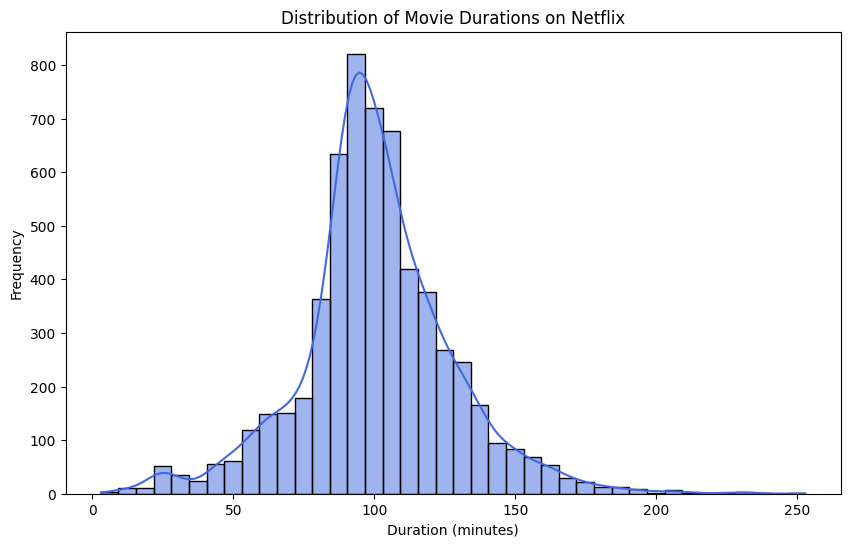

In [25]:
plt.figure(figsize = (10,6))
sns.histplot(data =df_movies, x = 'duration_minutes', bins = 40, kde = True, color = 'Royalblue')
plt.title('Distribution of Movie Durations on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

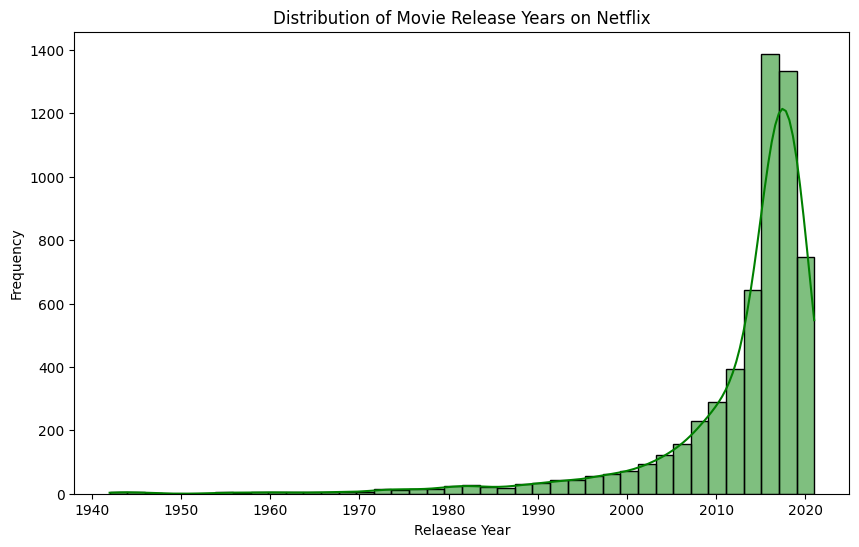

In [26]:
plt.figure(figsize = (10,6))
sns.histplot(data = df_movies, x = 'release_year', bins = 40, kde = True, color = 'green')
plt.title('Distribution of Movie Release Years on Netflix')
plt.xlabel('Relaease Year')
plt.ylabel('Frequency')
plt.show()

#### Categorical (rating, country, director, listed in)

<function matplotlib.pyplot.show(close=None, block=None)>

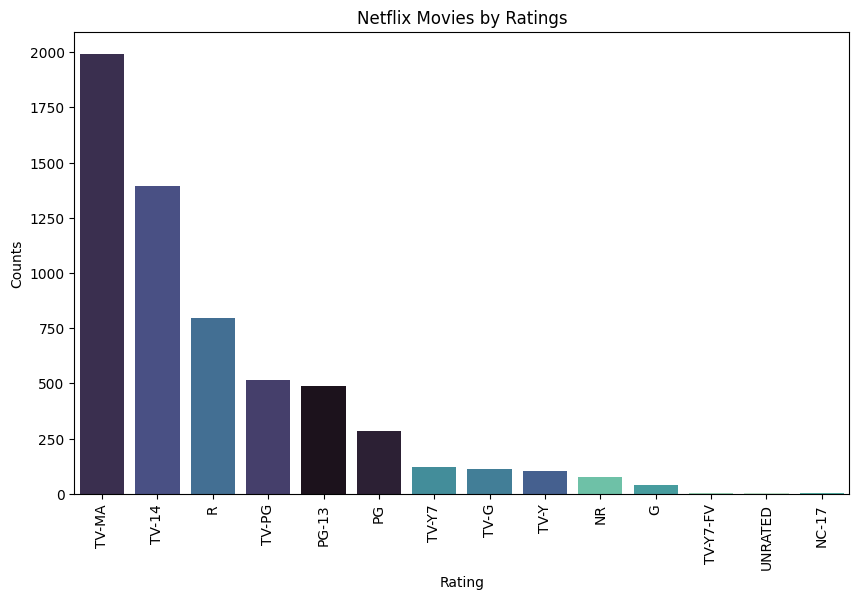

In [27]:
plt.figure(figsize = (10,6))
order = df_movies['rating'].value_counts().index
sns.countplot(data = df_movies, x = 'rating', order = order, palette = 'mako', hue = 'rating', legend = False,)
plt.xticks(rotation=90)
plt.title('Netflix Movies by Ratings')
plt.xlabel('Rating')
plt.ylabel('Counts')
plt.show

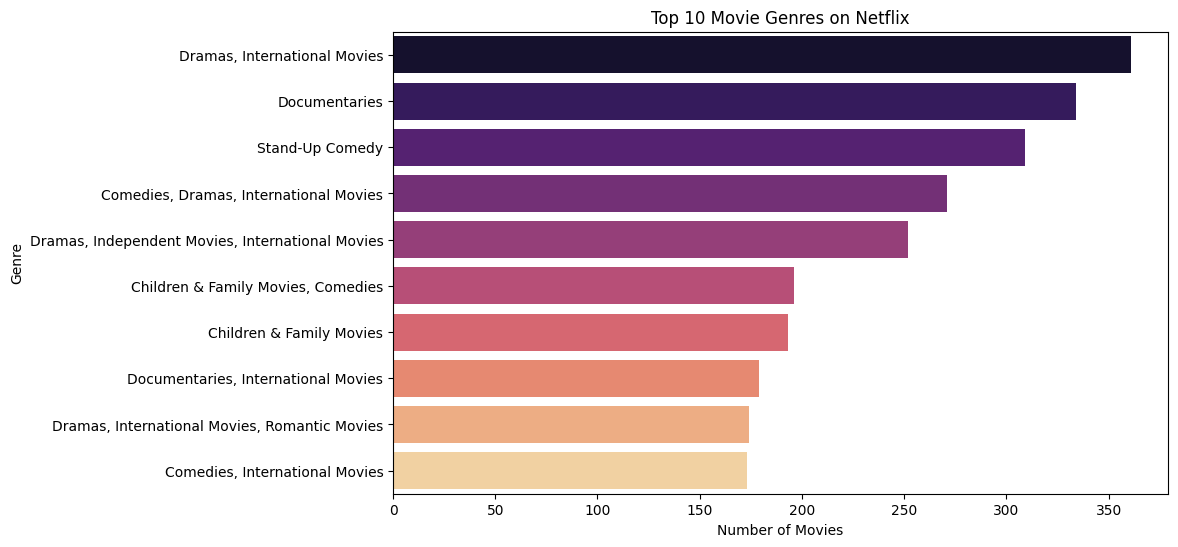

In [28]:
plt.figure(figsize=(10, 6))
valid_Genres = df_movies[df_movies['listed_in'] != 'Unknown']
top_10_genres = valid_Genres['listed_in'].value_counts().head(10)
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='magma', hue = top_10_genres.index, legend = False )
plt.title('Top 10 Movie Genres on Netflix')
plt.xlabel('Number of Movies')
plt.ylabel('Genre')
plt.show()

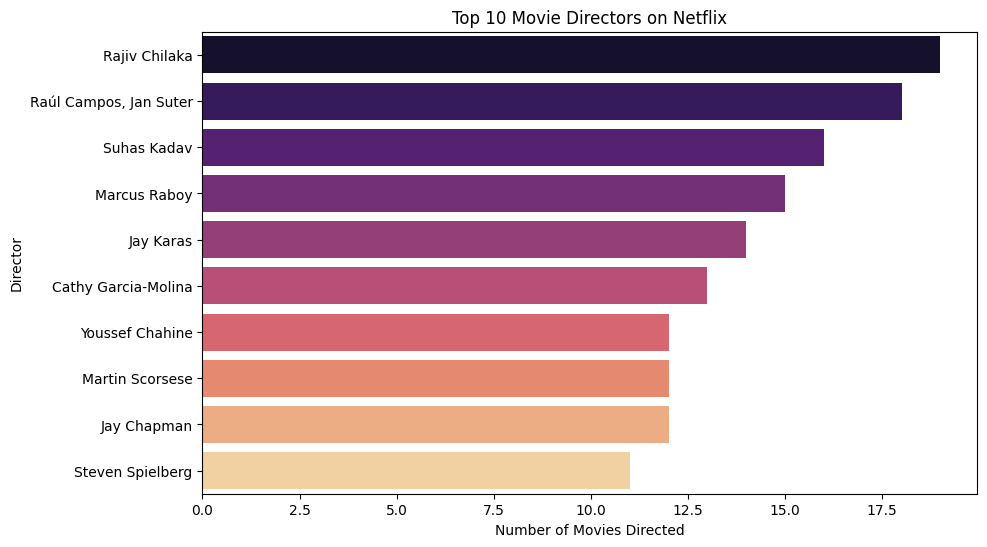

In [29]:
plt.figure(figsize=(10, 6))
valid_directors = df_movies[df_movies['director'] != 'Unknown']
top_10_directors = valid_directors['director'].value_counts().head(10)
sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='magma', hue = top_10_directors.index, legend = False )
plt.title('Top 10 Movie Directors on Netflix')
plt.xlabel('Number of Movies Directed')
plt.ylabel('Director')
plt.show()

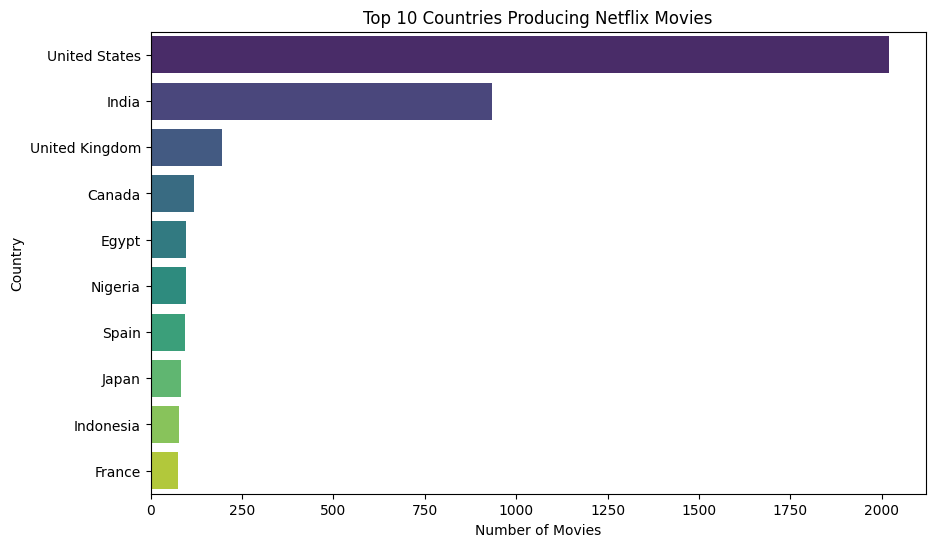

In [30]:
plt.figure(figsize=(10, 6))
valid_country = df_movies[df_movies['country'] != 'Unknown']
top_10_country = valid_country['country'].value_counts().head(10)
sns.barplot(x=top_10_country.values, y=top_10_country.index, palette='viridis', hue = top_10_country.index, legend = False )
plt.title('Top 10 Countries Producing Netflix Movies')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.show()

### TVshows


#### Overview

In [31]:
df_TVshows.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 2664 entries, 2021-09-24 to 2019-07-01
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   type          2664 non-null   str  
 1   title         2664 non-null   str  
 2   cast          2664 non-null   str  
 3   country       2664 non-null   str  
 4   release_year  2664 non-null   int64
 5   rating        2664 non-null   str  
 6   duration      2664 non-null   str  
 7   listed_in     2664 non-null   str  
 8   description   2664 non-null   str  
 9   season_count  2664 non-null   int64
dtypes: int64(2), str(8)
memory usage: 228.9 KB


In [32]:
df_TVshows.head()

,type,title,cast,country,release_year,rating,duration,listed_in,description,season_count
date_added,,,,,,,,,,
2021-09-24,TV Show,Blood & Water,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2
2021-09-24,TV Show,Ganglands,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,1
2021-09-24,TV Show,Jailbirds New Orleans,Not listed,Unknown,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",1
2021-09-24,TV Show,Kota Factory,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2
2021-09-24,TV Show,Midnight Mass,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",Unknown,2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,1


#### Numerical columns (season count, release year)

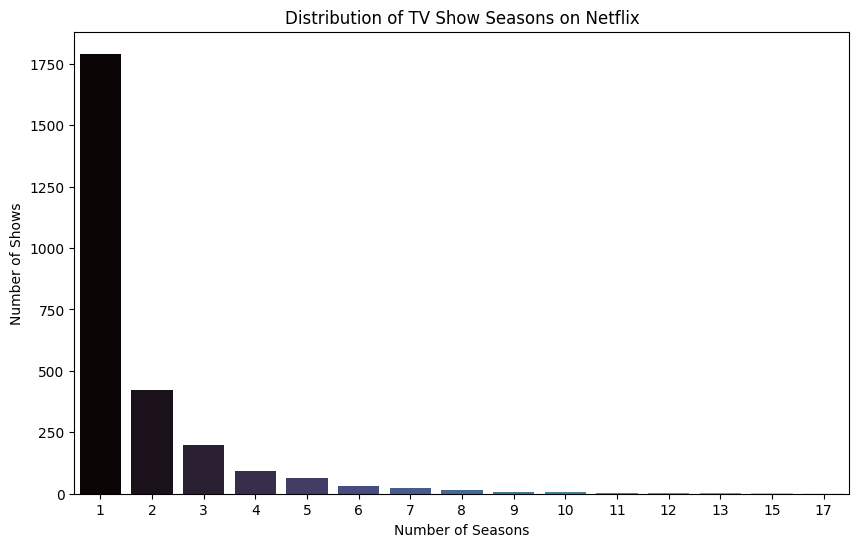

In [33]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_TVshows, x='season_count', palette='mako', hue = 'season_count', legend = False)
plt.title('Distribution of TV Show Seasons on Netflix')
plt.xlabel('Number of Seasons')
plt.ylabel('Number of Shows')
plt.show()

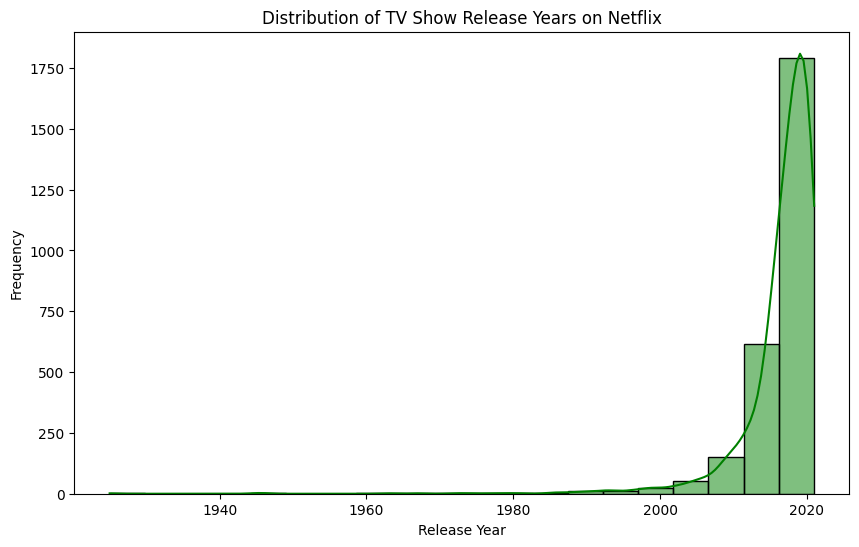

In [34]:
plt.figure(figsize = (10,6))
sns.histplot(data = df_TVshows, x = 'release_year', bins = 20, kde = True, color = 'green')
plt.title('Distribution of TV Show Release Years on Netflix')
plt.xlabel('Release Year')
plt.ylabel('Frequency')
plt.show()

#### Categorical (rating, country, listed in )

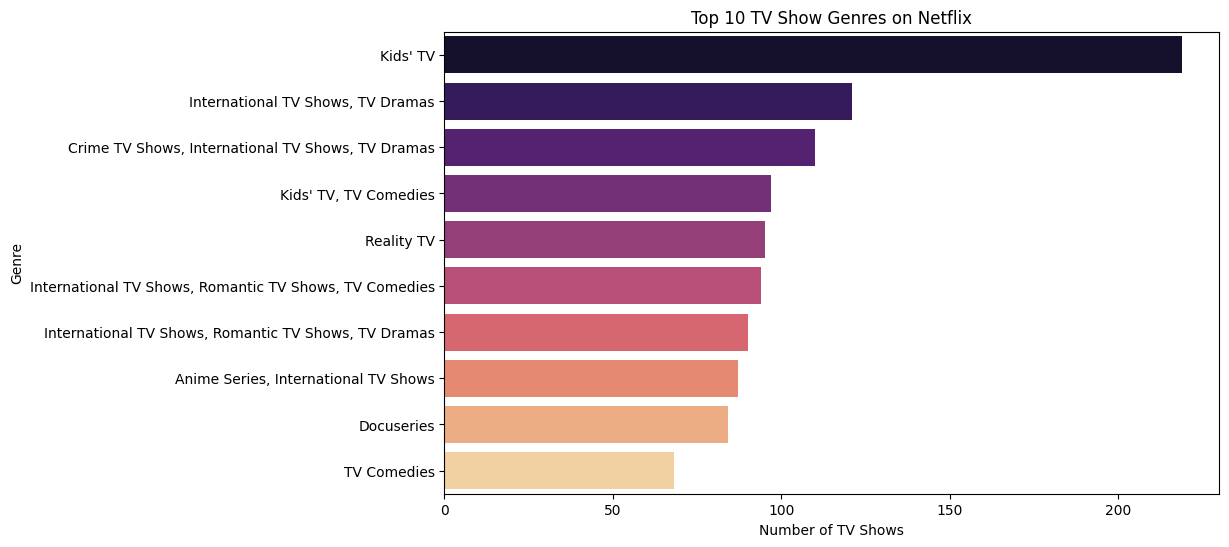

In [35]:
plt.figure(figsize=(10, 6))
valid_Genres = df_TVshows[df_TVshows['listed_in'] != 'Unknown']
top_10_genres = valid_Genres['listed_in'].value_counts().head(10)
sns.barplot(x=top_10_genres.values, y=top_10_genres.index, palette='magma', hue = top_10_genres.index, legend = False )
plt.title('Top 10 TV Show Genres on Netflix')
plt.xlabel('Number of TV Shows')
plt.ylabel('Genre')
plt.show()

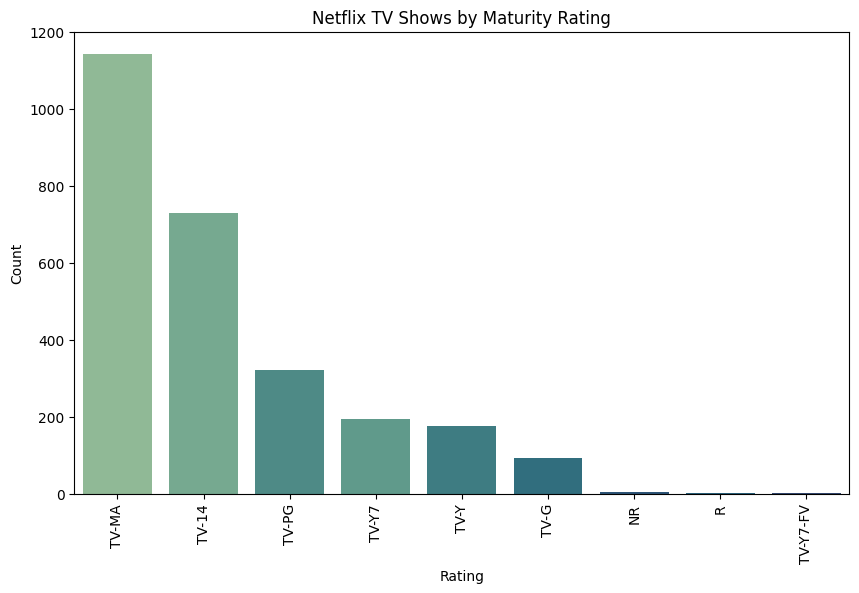

In [36]:
plt.figure(figsize=(10, 6))
order = df_TVshows['rating'].value_counts().index
sns.countplot(data=df_TVshows, x='rating',order=order, palette='crest', hue = 'rating', legend = False)
plt.xticks(rotation=90)  
plt.title('Netflix TV Shows by Maturity Rating')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

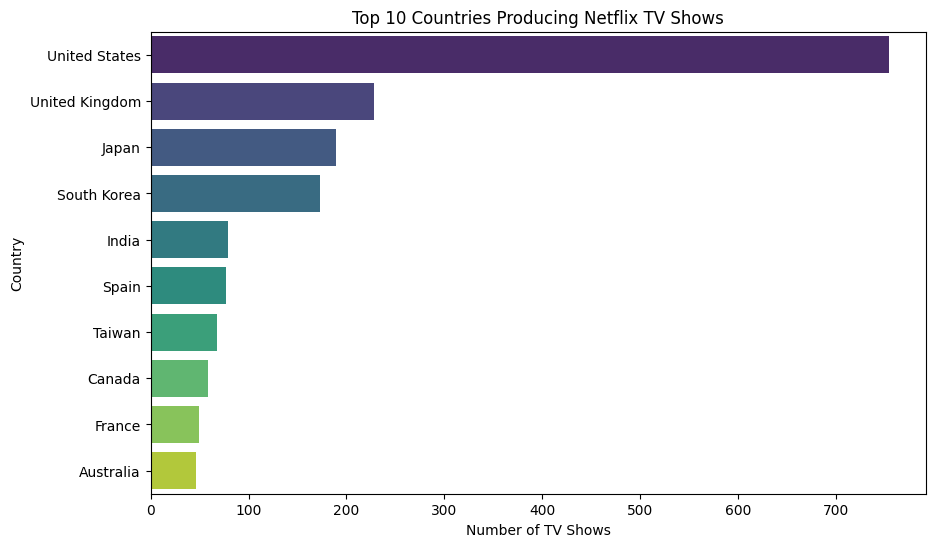

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
valid_country = df_TVshows[df_TVshows['country'] != 'Unknown']
top_10_country = valid_country['country'].value_counts().head(10)
sns.barplot(x=top_10_country.values, y=top_10_country.index, palette='viridis', hue = top_10_country.index, legend = False )
plt.title('Top 10 Countries Producing Netflix TV Shows')
plt.xlabel('Number of TV Shows')
plt.ylabel('Country')
plt.show()

## Bivariate Analysis

### Movies

#### Categorical Vs Numerical

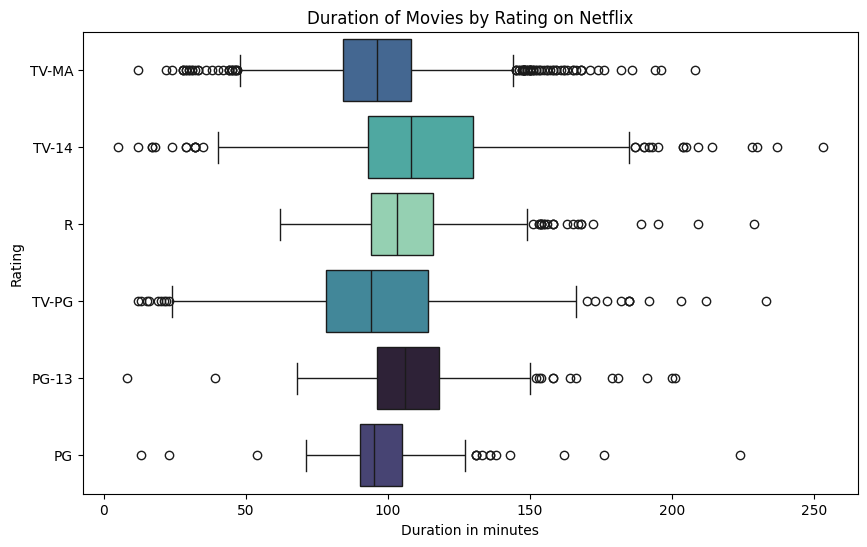

In [38]:
top_6_ratings = df_movies['rating'].value_counts().head(6).index
df_filtered_movies = df_movies[df_movies['rating'].isin(top_6_ratings)]
plt.figure(figsize = (10,6))
order = top_6_ratings
sns.boxplot(data = df_filtered_movies,  x = 'duration_minutes', y = 'rating',order = order, palette = 'mako', hue = 'rating', legend = False)
plt.title('Duration of Movies by Rating on Netflix')
plt.xlabel('Duration in minutes')
plt.ylabel('Rating')
plt.show()

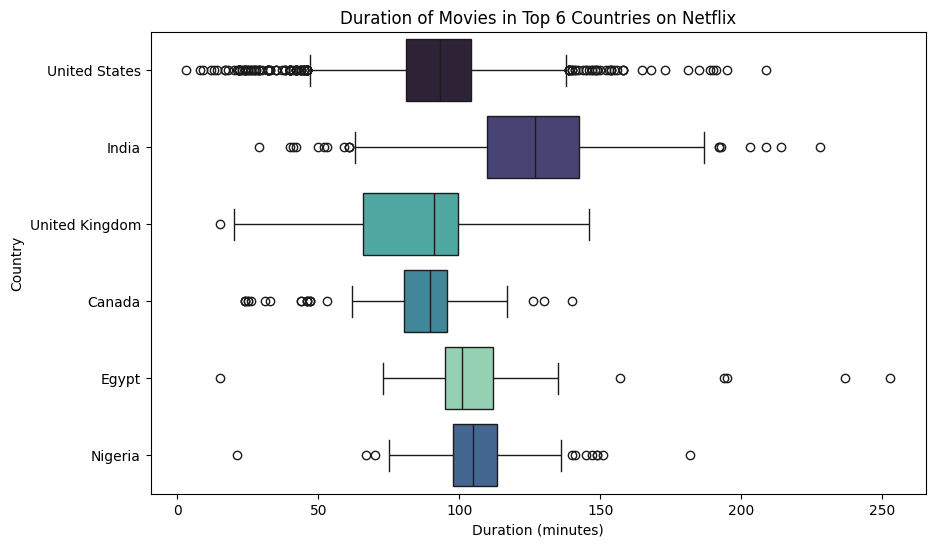

In [39]:
valid_countries = df_movies[df_movies['country'] != 'Unknown']
top_6_genres = valid_countries['country'].value_counts().head(6).index
df_filtered_movies = valid_countries[valid_countries['country'].isin(top_6_genres)]
plt.figure(figsize = (10,6))
order = top_6_genres
sns.boxplot(data = df_filtered_movies,  x = 'duration_minutes', y = 'country',order = order, palette = 'mako', hue = 'country', legend = False)
plt.title('Duration of Movies in Top 6 Countries on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Country')
plt.show()

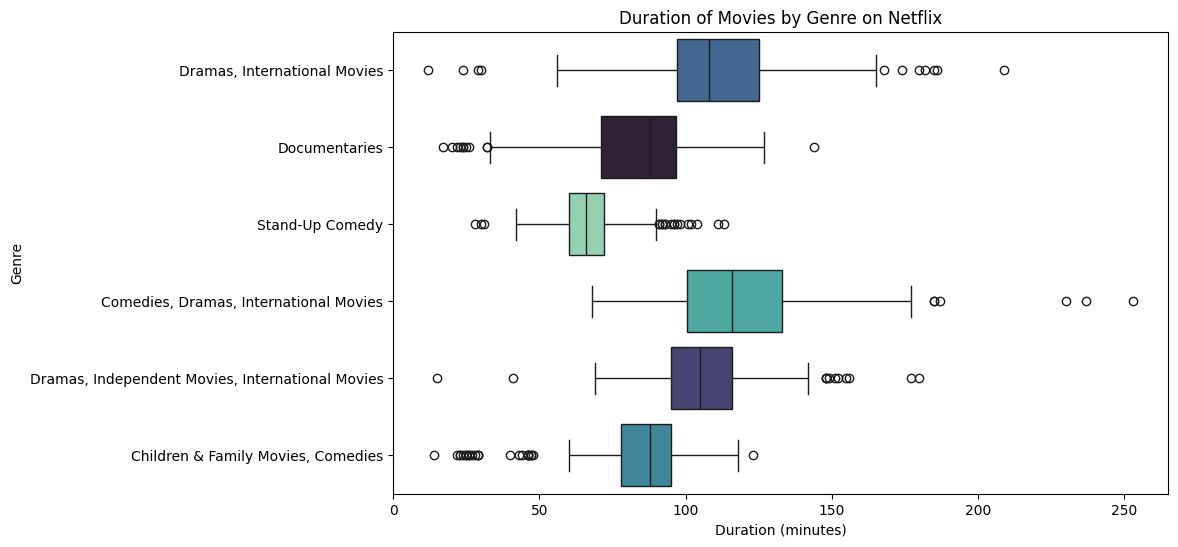

In [40]:
top_6_genres = df_movies['listed_in'].value_counts().head(6).index
df_filtered_movies = df_movies[df_movies['listed_in'].isin(top_6_genres)]
plt.figure(figsize = (10,6))
order = top_6_genres
sns.boxplot(data = df_filtered_movies,  x = 'duration_minutes', y = 'listed_in',order = order, palette = 'mako', hue = 'listed_in', legend = False)
plt.title('Duration of Movies by Genre on Netflix')
plt.xlabel('Duration (minutes)')
plt.ylabel('Genre')
plt.show()

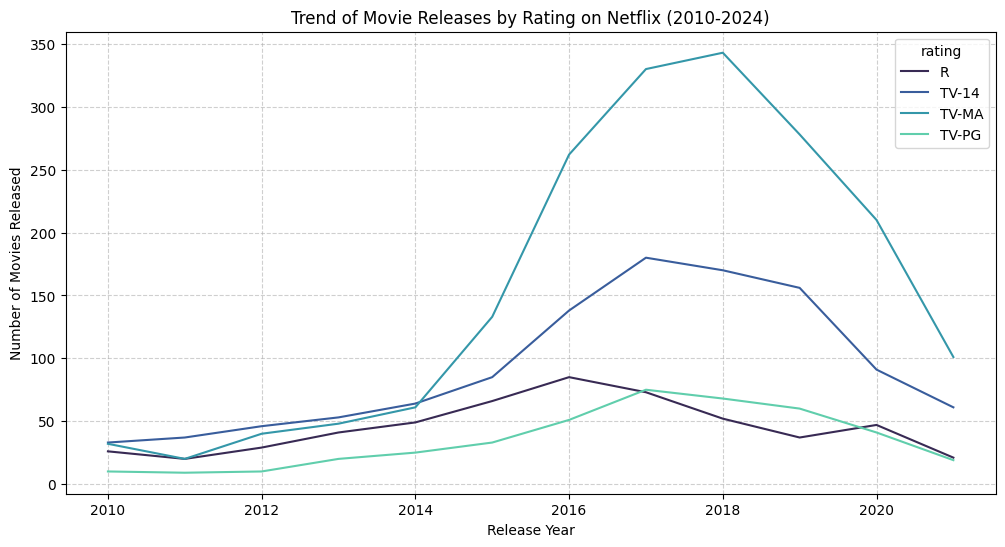

In [41]:
recent_movies = df_movies[df_movies['release_year'] >= 2010]
top_4_ratings = recent_movies['rating'].value_counts().head(4).index
df_trend = recent_movies[recent_movies['rating'].isin(top_4_ratings)]
trend_data = df_trend.groupby(['release_year', 'rating']).size().reset_index(name='movie_count')

plt.figure(figsize = (12,6))
sns.lineplot(data = trend_data, x = 'release_year', y = 'movie_count', hue = 'rating', palette = 'mako')
plt.title('Trend of Movie Releases by Rating on Netflix (2010-2024)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a subtle grid to help track the years
plt.show()

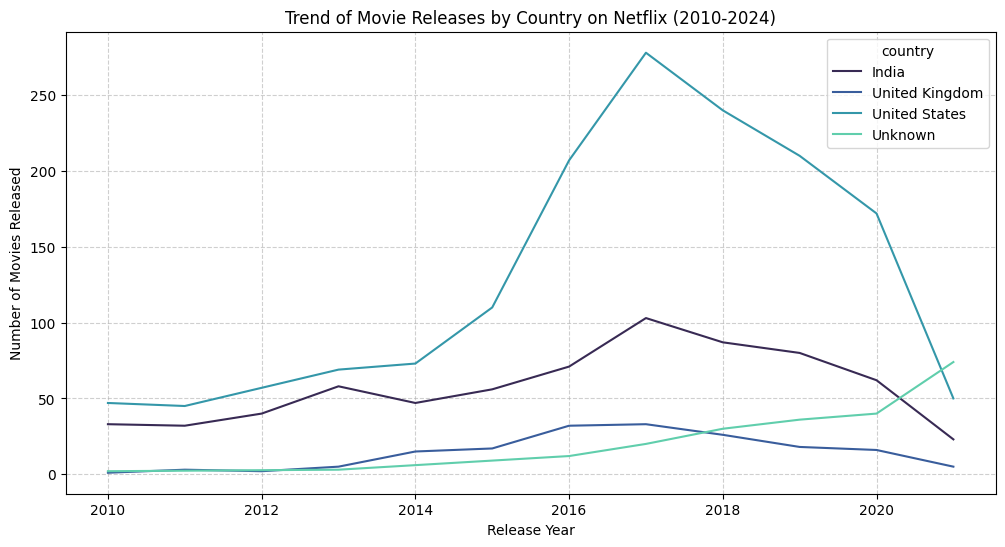

In [42]:
recent_movies = df_movies[df_movies['release_year'] >= 2010]
top_4_countries = recent_movies['country'].value_counts().head(4).index
df_trend = recent_movies[recent_movies['country'].isin(top_4_countries)]
trend_data = df_trend.groupby(['release_year', 'country']).size().reset_index(name='movie_count')

plt.figure(figsize = (12,6))
sns.lineplot(data = trend_data, x = 'release_year', y = 'movie_count', hue = 'country', palette = 'mako')
plt.title('Trend of Movie Releases by Country on Netflix (2010-2024)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a subtle grid to help track the years
plt.show()

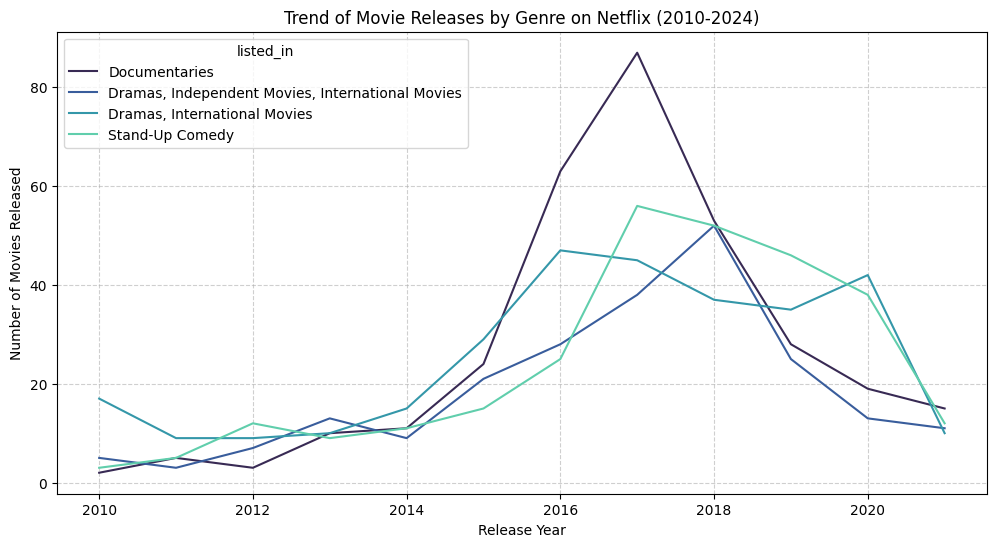

In [43]:
recent_movies = df_movies[df_movies['release_year'] >= 2010]
top_4_listed_in = recent_movies['listed_in'].value_counts().head(4).index
df_trend = recent_movies[recent_movies['listed_in'].isin(top_4_listed_in)]
trend_data = df_trend.groupby(['release_year', 'listed_in']).size().reset_index(name='movie_count')

plt.figure(figsize = (12,6))
sns.lineplot(data = trend_data, x = 'release_year', y = 'movie_count', hue = 'listed_in', palette = 'mako')
plt.title('Trend of Movie Releases by Genre on Netflix (2010-2024)')
plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released')
plt.grid(True, linestyle='--', alpha=0.6) 
plt.show()

#### Categorical Vs Categorical


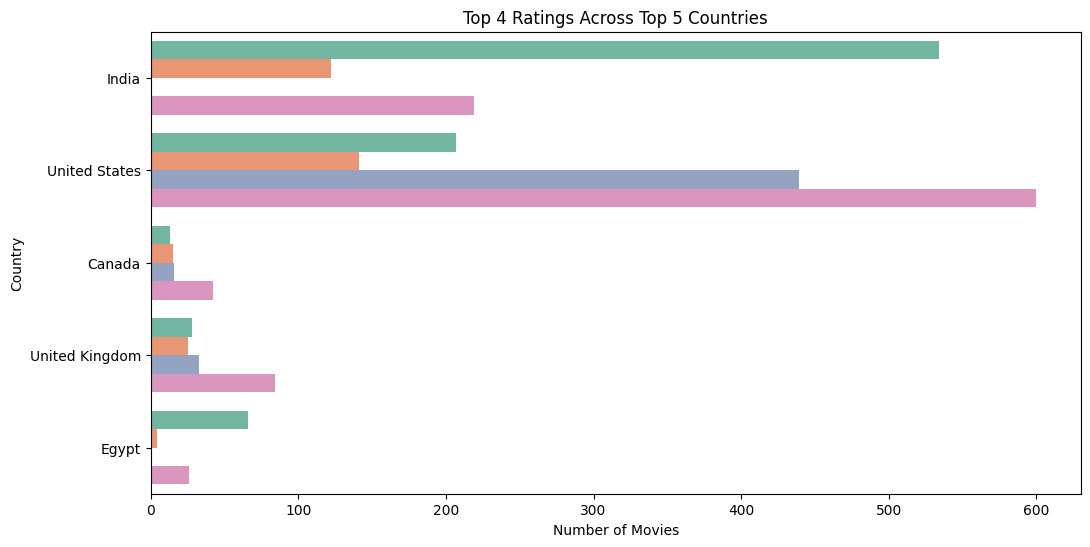

In [44]:
valid_countries = df_movies[df_movies['country'] != 'Unknown']
top_5_countries = valid_countries['country'].value_counts().head(5).index
top_4_ratings = df_movies['rating'].value_counts().head(4).index
df_cat_filtered = df_movies[df_movies['country'].isin(top_5_countries) & df_movies['rating'].isin(top_4_ratings)]
plt.figure(figsize = (12,6))
sns.countplot(data = df_cat_filtered, y = 'country', hue = 'rating', palette = 'Set2', legend = False)
plt.title('Top 4 Ratings Across Top 5 Countries')
plt.xlabel('Number of Movies')
plt.ylabel('Country')
plt.show()

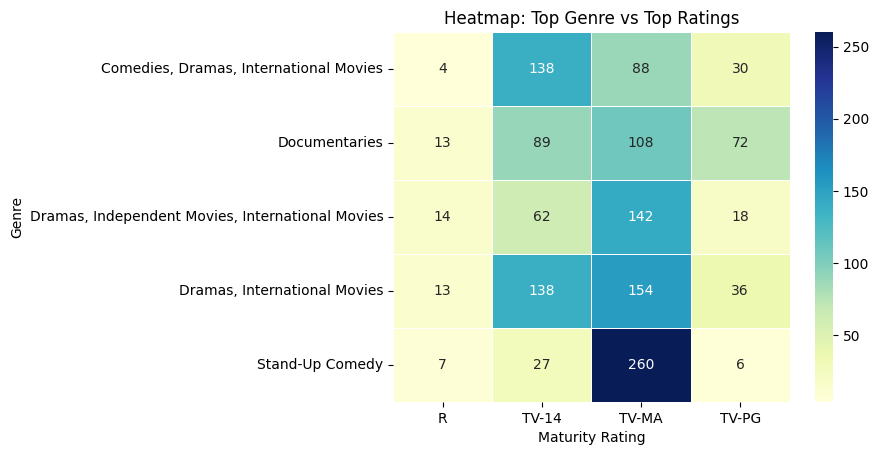

In [45]:
top_5_genres = df_movies['listed_in'].value_counts().head(5).index
df_genre_filtered = df_movies[df_movies['listed_in'].isin(top_5_genres)]
df_genre_rating = df_genre_filtered[df_genre_filtered['rating'].isin(top_4_ratings)]
crosstab_data = pd.crosstab(df_genre_rating.reset_index()['listed_in'], df_genre_rating.reset_index()['rating'])
sns.heatmap(crosstab_data, annot = True, fmt = 'd', cmap = 'YlGnBu',linewidths = 0.5)
plt.title('Heatmap: Top Genre vs Top Ratings')
plt.xlabel('Maturity Rating')
plt.ylabel('Genre')
plt.show()

#### Numerical Vs Numerical

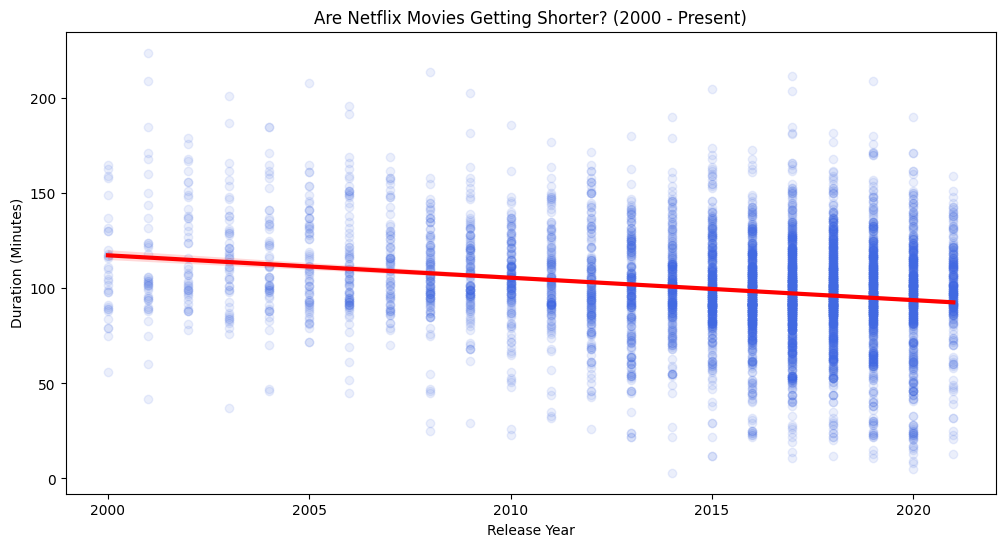

In [46]:
plt.figure(figsize=(12, 6))
recent_movies = df_movies[df_movies['release_year'] >= 2000]
sns.regplot(data=recent_movies, 
            x='release_year', 
            y='duration_minutes', 
            
            scatter_kws={'alpha': 0.1, 'color': 'royalblue'}, 
            
            line_kws={'color': 'red', 'linewidth': 3})

plt.title('Are Netflix Movies Getting Shorter? (2000 - Present)')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.show()

### TV shows

#### Categorical VS Numerical 

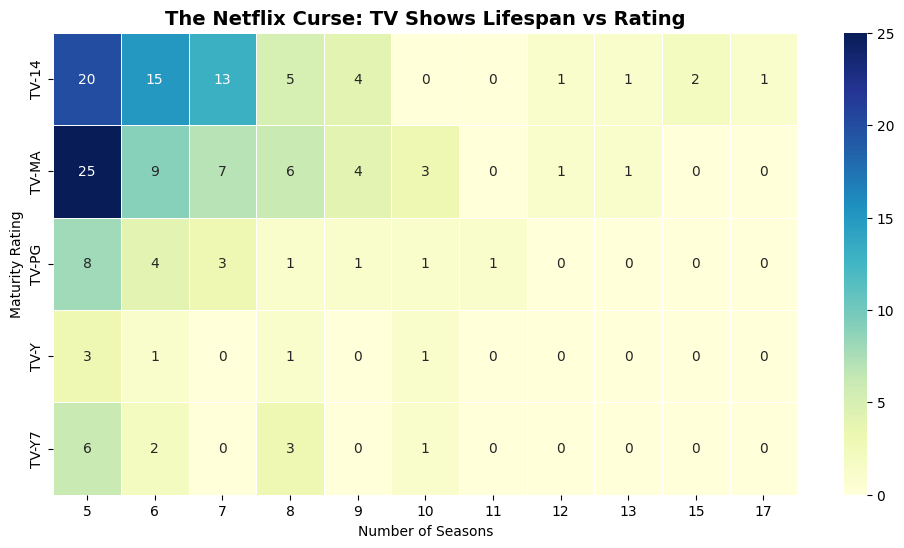

In [47]:
df_tv_core = df_TVshows[df_TVshows['season_count'] >= 5]
top_5_ratings_tv = df_tv_core['rating'].value_counts().head(5).index
df_tv_core = df_tv_core[df_tv_core['rating'].isin(top_5_ratings_tv)]
tv_crosstab = pd.crosstab(df_tv_core['rating'].values, df_tv_core['season_count'].values)
plt.figure(figsize = (12,6))
sns.heatmap(tv_crosstab, annot = True, fmt ='d',cmap = 'YlGnBu', linewidths = 0.5)
plt.title('The Netflix Curse: TV Shows Lifespan vs Rating', fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Maturity Rating')
plt.show()


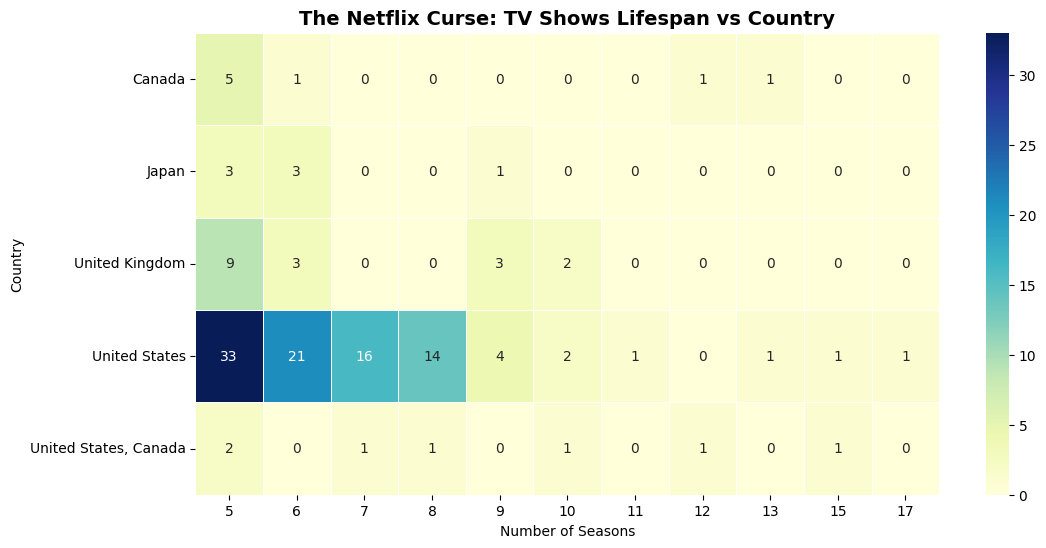

In [48]:
df_tv_core = df_TVshows[df_TVshows['season_count'] >= 5]
top_5_country_tv = df_tv_core['country'].value_counts().head(5).index
df_tv_core = df_tv_core[df_tv_core['country'].isin(top_5_country_tv)]
tv_crosstab = pd.crosstab(df_tv_core['country'].values, df_tv_core['season_count'].values)
plt.figure(figsize = (12,6))
sns.heatmap(tv_crosstab, annot = True, fmt ='d',cmap = 'YlGnBu', linewidths = 0.5)
plt.title('The Netflix Curse: TV Shows Lifespan vs Country', fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Country')
plt.show()


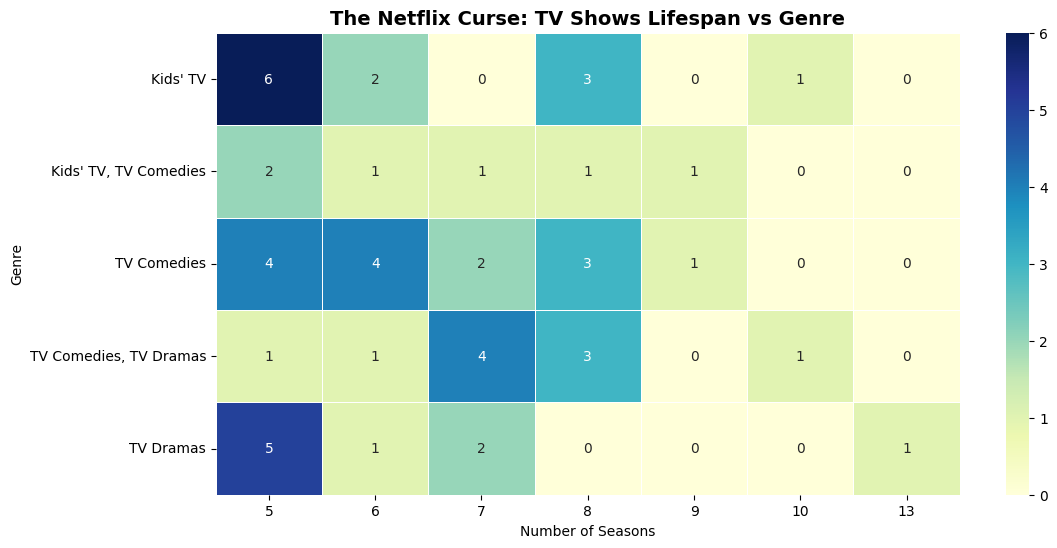

In [49]:
df_tv_core = df_TVshows[df_TVshows['season_count'] >= 5]
top_5_genres_tv = df_tv_core['listed_in'].value_counts().head(5).index
df_tv_core = df_tv_core[df_tv_core['listed_in'].isin(top_5_genres_tv)]
tv_crosstab = pd.crosstab(df_tv_core['listed_in'].values, df_tv_core['season_count'].values)
plt.figure(figsize = (12,6))
sns.heatmap(tv_crosstab, annot = True, fmt ='d',cmap = 'YlGnBu', linewidths = 0.5)
plt.title('The Netflix Curse: TV Shows Lifespan vs Genre', fontsize = 14, fontweight = 'bold')
plt.xlabel('Number of Seasons')
plt.ylabel('Genre')
plt.show()


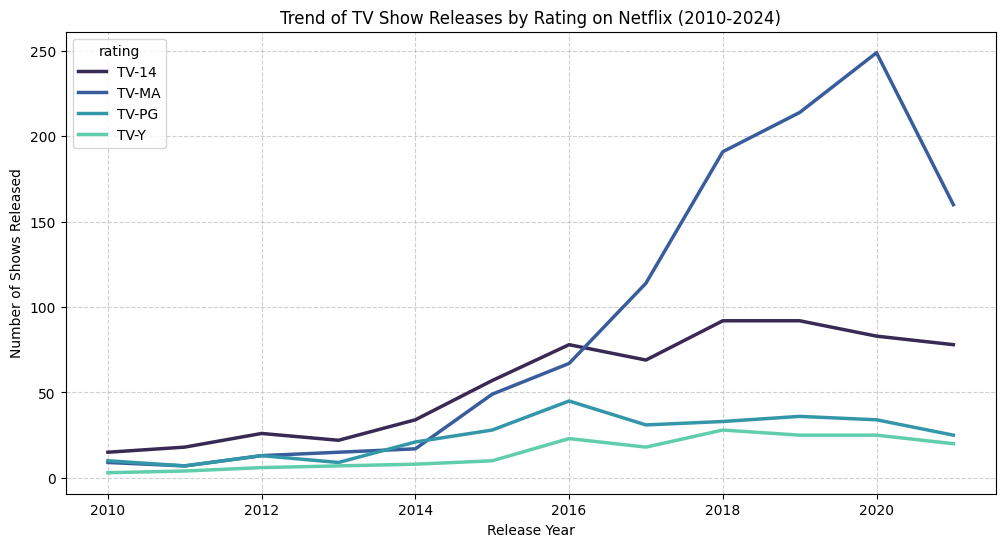

In [50]:
recent_tvshows = df_TVshows[df_TVshows['release_year'] >= 2010]
top_4_ratings = recent_tvshows['rating'].value_counts().head(4).index
df_trend = recent_tvshows[recent_tvshows['rating'].isin(top_4_ratings)]
trend_data = df_trend.groupby(['release_year', 'rating']).size().reset_index(name='shows_count')

plt.figure(figsize = (12,6))
sns.lineplot(data = trend_data, x = 'release_year', y = 'shows_count', hue = 'rating', linewidth=2.5, palette = 'mako')
plt.title('Trend of TV Show Releases by Rating on Netflix (2010-2024)')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows Released')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a subtle grid to help track the years
plt.show()

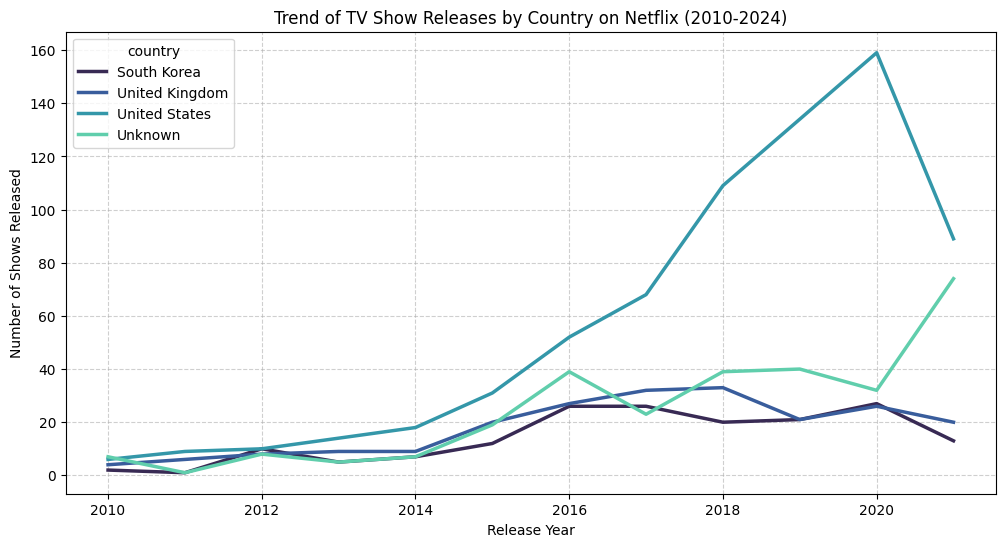

In [51]:
recent_tvshows = df_TVshows[df_TVshows['release_year'] >= 2010]
top_4_ratings = recent_tvshows['country'].value_counts().head(4).index
df_trend = recent_tvshows[recent_tvshows['country'].isin(top_4_ratings)]
trend_data = df_trend.groupby(['release_year', 'country']).size().reset_index(name='shows_count')

plt.figure(figsize = (12,6))
sns.lineplot(data = trend_data, x = 'release_year', y = 'shows_count', hue = 'country', linewidth=2.5, palette = 'mako')
plt.title('Trend of TV Show Releases by Country on Netflix (2010-2024)')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows Released')
plt.grid(True, linestyle='--', alpha=0.6) # Adds a subtle grid to help track the years
plt.show()

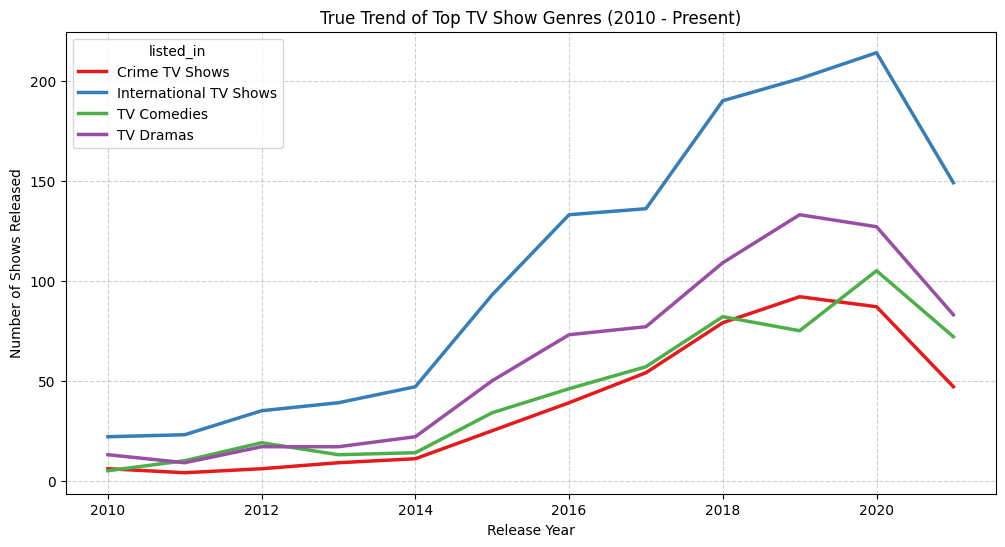

In [52]:
df_tv_exploded = df_TVshows.assign(listed_in=df_TVshows['listed_in'].str.split(', ')).explode('listed_in')
recent_tv = df_tv_exploded[df_tv_exploded['release_year'] >= 2010]
top_4_true_genres = recent_tv['listed_in'].value_counts().head(4).index
df_trend_tv = recent_tv[recent_tv['listed_in'].isin(top_4_true_genres)]
tv_trend_data = df_trend_tv.groupby(['release_year', 'listed_in']).size().reset_index(name='show_count')

plt.figure(figsize=(12, 6))
sns.lineplot(data=tv_trend_data, 
             x='release_year', 
             y='show_count', 
             hue='listed_in', 
             linewidth=2.5, 
             palette='Set1')

plt.title('True Trend of Top TV Show Genres (2010 - Present)')
plt.xlabel('Release Year')
plt.ylabel('Number of Shows Released')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

#### Categorical VS Categorical

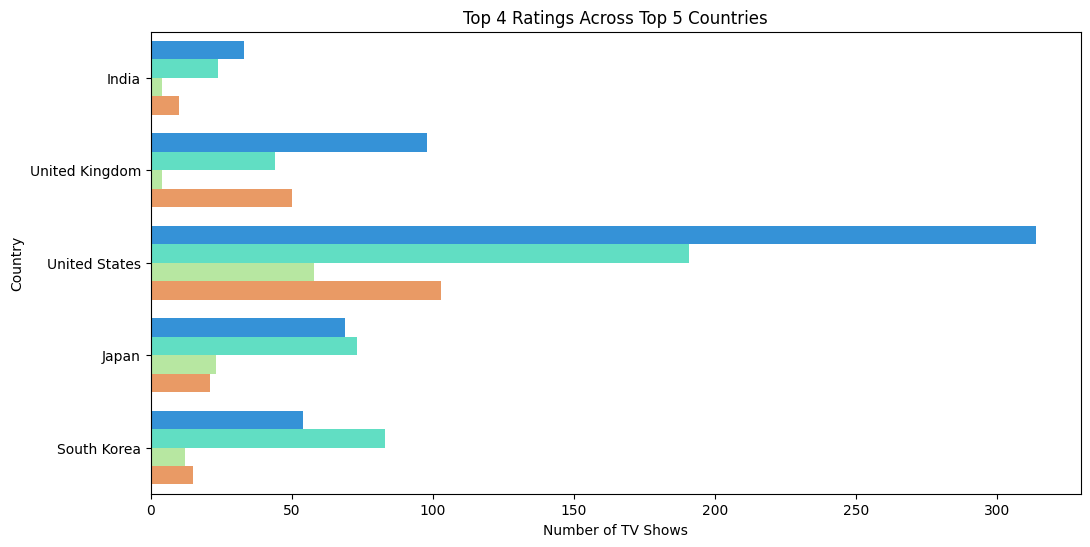

In [53]:
valid_countries = df_TVshows[df_TVshows['country'] != 'Unknown']
top_5_countries = valid_countries['country'].value_counts().head(5).index
top_4_ratings = df_TVshows['rating'].value_counts().head(4).index
df_cat_filtered = df_TVshows[df_TVshows['country'].isin(top_5_countries) & df_TVshows['rating'].isin(top_4_ratings)]
plt.figure(figsize = (12,6))
sns.countplot(data = df_cat_filtered, y = 'country', hue = 'rating', palette = 'rainbow', legend = False)
plt.title('Top 4 Ratings Across Top 5 Countries')
plt.xlabel('Number of TV Shows')
plt.ylabel('Country')
plt.show()

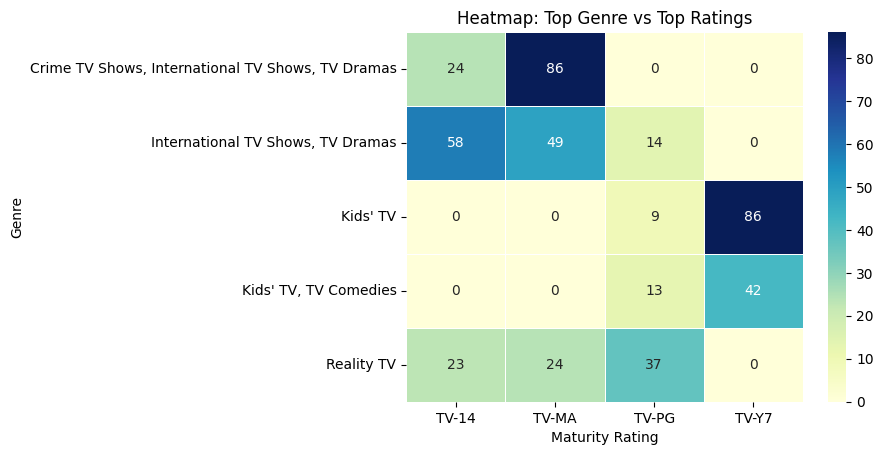

In [54]:
top_5_genres = df_TVshows['listed_in'].value_counts().head(5).index
df_genre_filtered = df_TVshows[df_TVshows['listed_in'].isin(top_5_genres)]
df_genre_rating = df_genre_filtered[df_genre_filtered['rating'].isin(top_4_ratings)]
crosstab_data = pd.crosstab(df_genre_rating.reset_index()['listed_in'], df_genre_rating.reset_index()['rating'])
sns.heatmap(crosstab_data, annot = True, fmt = 'd', cmap = 'YlGnBu',linewidths = 0.5)
plt.title('Heatmap: Top Genre vs Top Ratings')
plt.xlabel('Maturity Rating')
plt.ylabel('Genre')
plt.show()

#### Numerical Vs Numerical

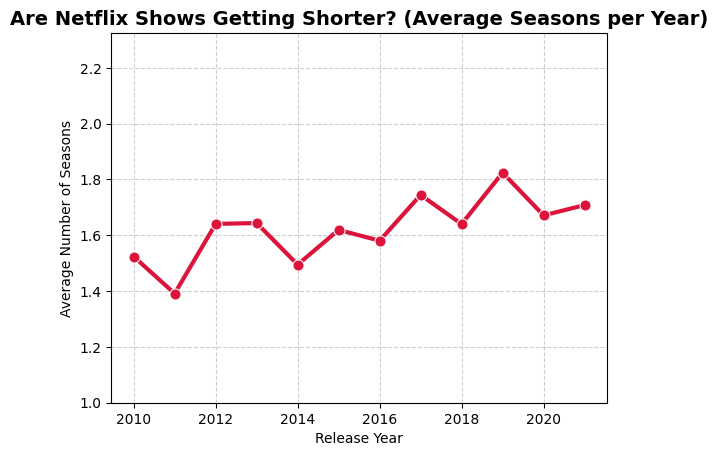

In [55]:
recent_tv = df_tv_exploded[df_tv_exploded['release_year'] >= 2010]
avg_seasons_per_year = recent_tv.groupby('release_year')['season_count'].mean().reset_index()
sns.lineplot(data=avg_seasons_per_year, 
             x='release_year', 
             y='season_count', 
             color='crimson', 
             linewidth=3,
             marker='o',         
             markersize=8)

plt.title('Are Netflix Shows Getting Shorter? (Average Seasons per Year)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Average Number of Seasons')
plt.grid(True, linestyle='--', alpha=0.6)

# Set the Y-axis to start at 1, since a show cannot have 0 seasons
plt.ylim(1, avg_seasons_per_year['season_count'].max() + 0.5) 
plt.show()

## Multivariate Analysis

### Movies

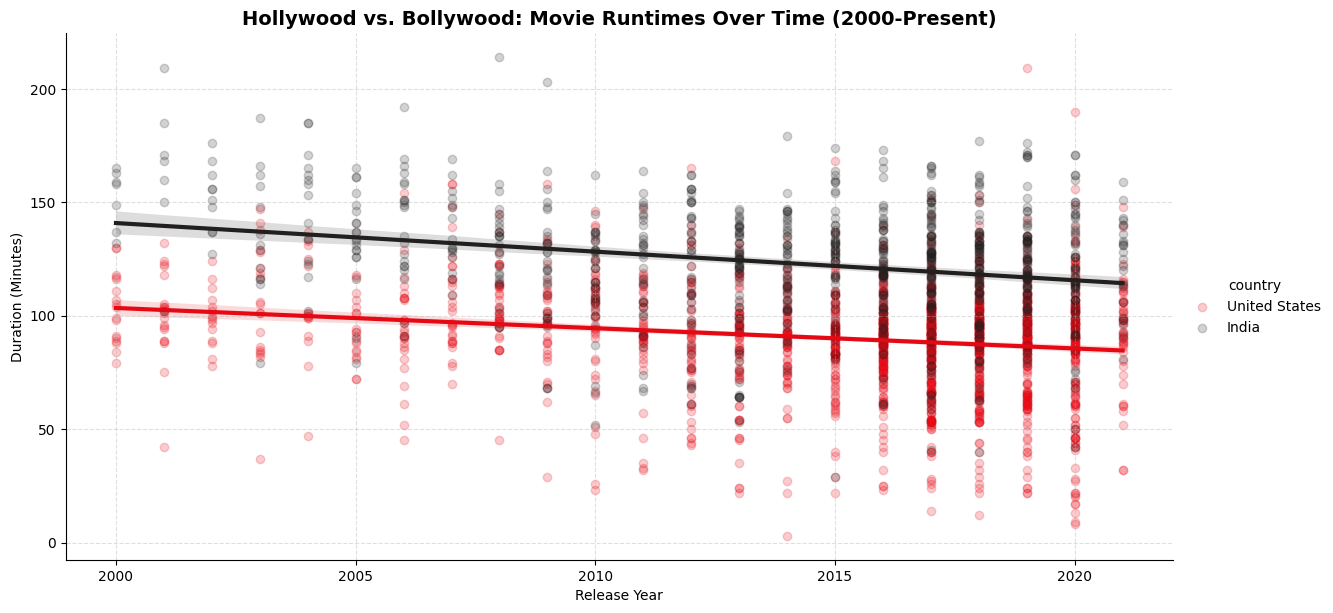

In [56]:
us_india_movies = df_movies[
    (df_movies['country'].isin(['United States', 'India'])) & 
    (df_movies['release_year'] >= 2000)]
sns.lmplot(data=us_india_movies, 
           x='release_year', 
           y='duration_minutes', 
           hue='country',           
           palette=['#E50914', '#221F1F'], 
           height=6, 
           aspect=2,                
           scatter_kws={'alpha': 0.2},
           line_kws={'linewidth': 3})  

plt.title('Hollywood vs. Bollywood: Movie Runtimes Over Time (2000-Present)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Duration (Minutes)')
plt.grid(True, linestyle='--', alpha=0.4)
plt.show()

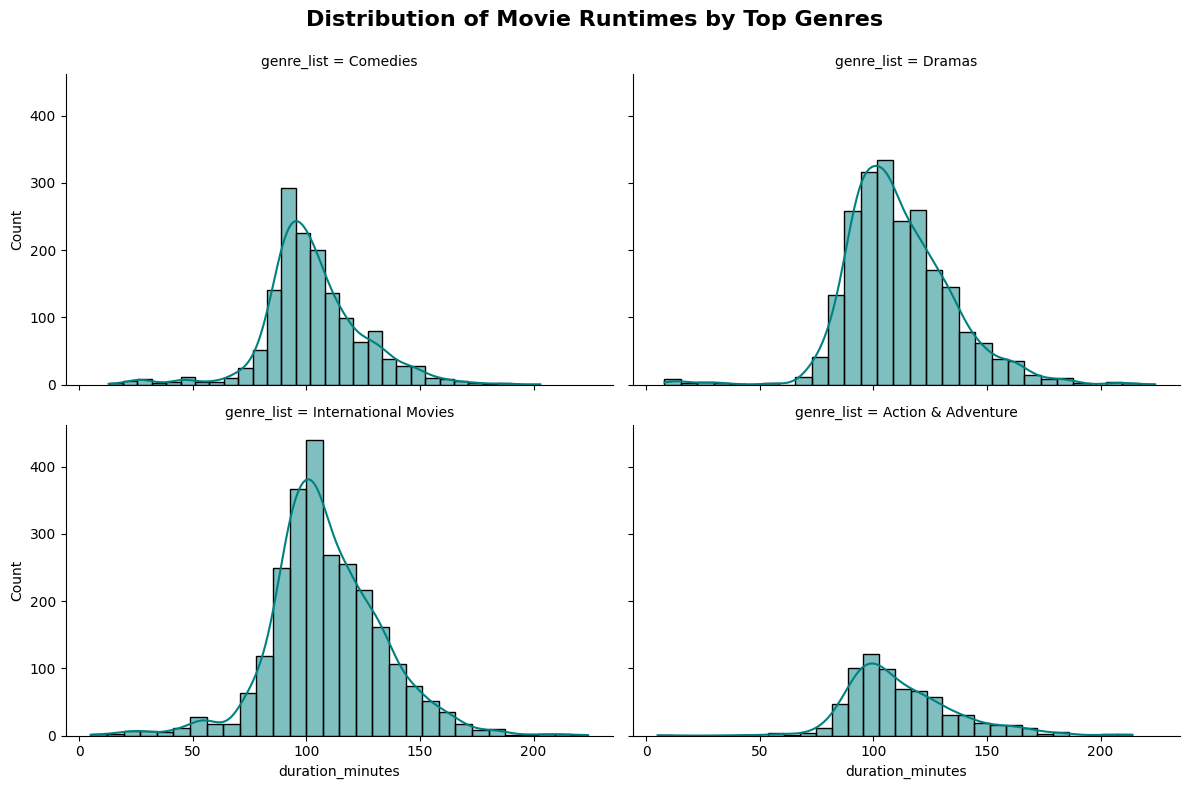

In [57]:
df_movies_genres = df_movies.assign(genre_list=df_movies['listed_in'].str.split(', ')).explode('genre_list')
top_4_genres = df_movies_genres['genre_list'].value_counts().head(4).index
df_multi_genre = df_movies_genres[
    (df_movies_genres['genre_list'].isin(top_4_genres)) & 
    (df_movies_genres['release_year'] >= 2000)
]
grid = sns.FacetGrid(df_multi_genre, col='genre_list', col_wrap=2, height=4, aspect=1.5)
grid.map_dataframe(sns.histplot, x='duration_minutes', kde=True, bins=30, color='teal')
grid.figure.subplots_adjust(top=0.9)
grid.figure.suptitle('Distribution of Movie Runtimes by Top Genres', fontsize=16, fontweight='bold')
plt.show()

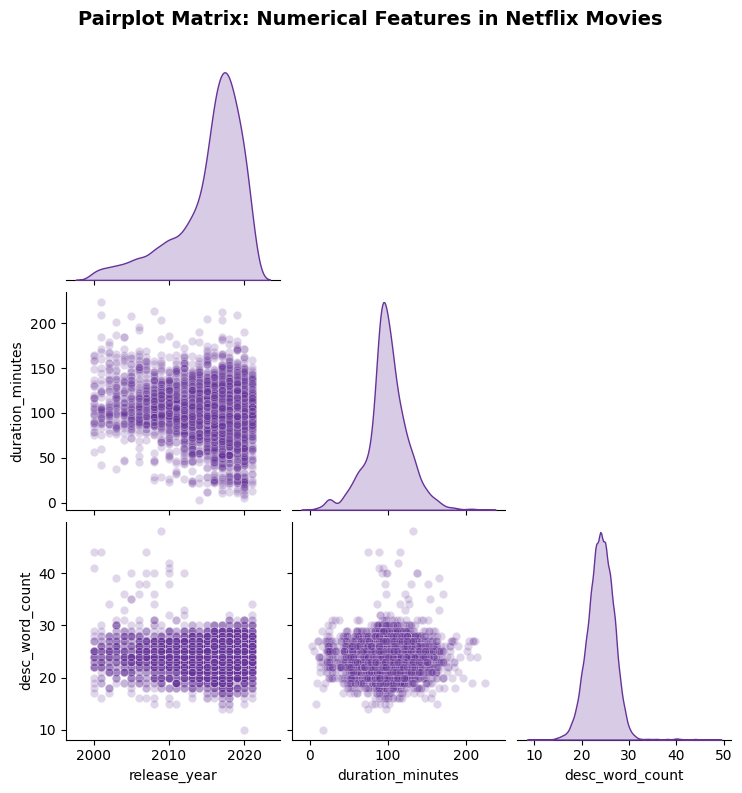

In [58]:
df_movies['desc_word_count'] = df_movies['description'].apply(lambda x: len(str(x).split()))
recent_movies = df_movies[df_movies['release_year'] >= 2000]
numerical_features = ['release_year', 'duration_minutes', 'desc_word_count']
df_ml_prep = recent_movies[numerical_features]
sns.pairplot(df_ml_prep, 
             corner=True,       
             diag_kind='kde',   
             plot_kws={'alpha': 0.2, 'color': 'rebeccapurple'}, 
             diag_kws={'fill': True, 'color': 'rebeccapurple'})

plt.suptitle('Pairplot Matrix: Numerical Features in Netflix Movies', y=1.05, fontsize=14, fontweight='bold')
plt.show()

### TV Shows

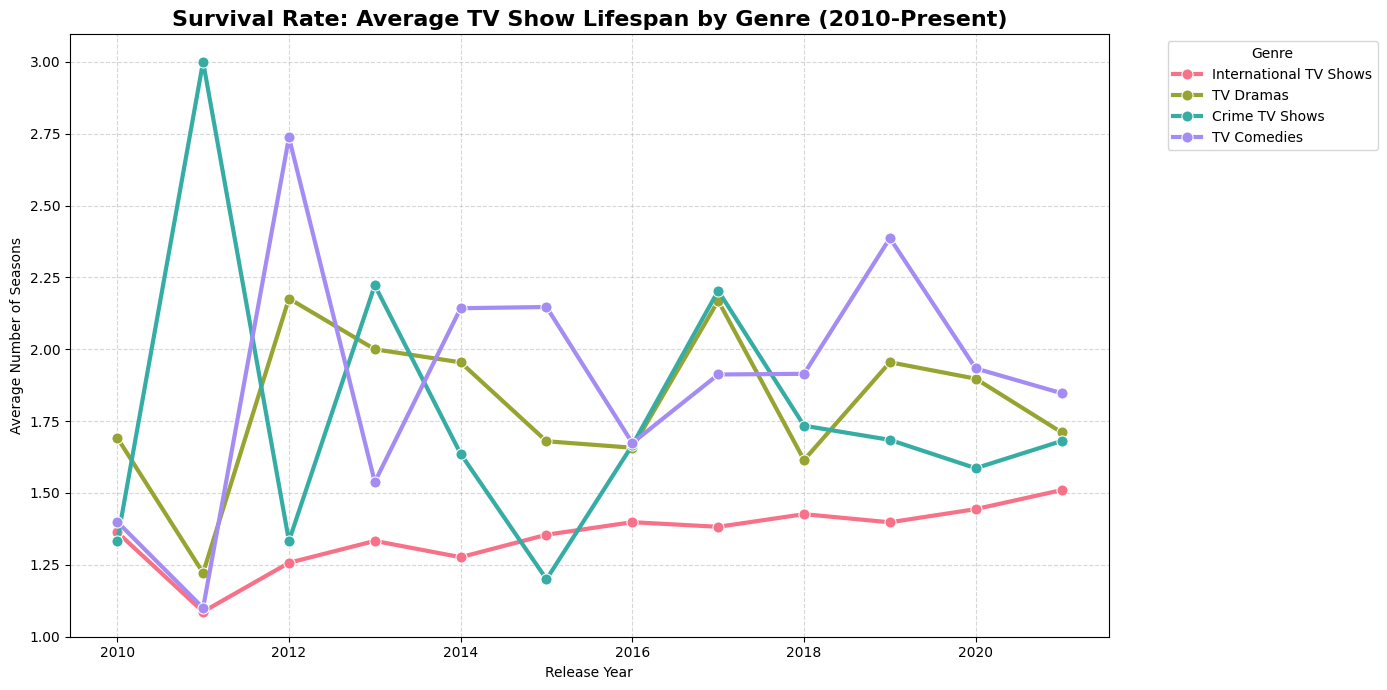

In [59]:
recent_tv = df_tv_exploded[df_tv_exploded['release_year'] >= 2010]

# Grab the Top 4 Genres
top_4_tv_genres = recent_tv['listed_in'].value_counts().head(4).index
df_multi_tv = recent_tv[recent_tv['listed_in'].isin(top_4_tv_genres)]


# --- 2. THE MULTIVARIATE PLOT ---
plt.figure(figsize=(14, 7))

# Plotting Time vs. Seasons, split by Genre
sns.lineplot(data=df_multi_tv, 
             x='release_year', 
             y='season_count', 
             hue='listed_in',       # The 3rd Variable!
             linewidth=3, 
             palette='husl',        # A vibrant, distinct color palette
             errorbar=None,         # Turns off the blurry statistical shadow around the lines
             marker='o',            # Adds a dot at every year
             markersize=8)


plt.title('Survival Rate: Average TV Show Lifespan by Genre (2010-Present)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Average Number of Seasons')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left') # Moves legend outside
plt.grid(True, linestyle='--', alpha=0.5)

# Start Y-axis at 1 (since 0 seasons isn't possible)
# This tells it to start at 1, but lets the top (None) auto-scale to the lines!
plt.ylim(1, None)
plt.tight_layout() # Ensures the legend doesn't get cut off when exporting
plt.show()

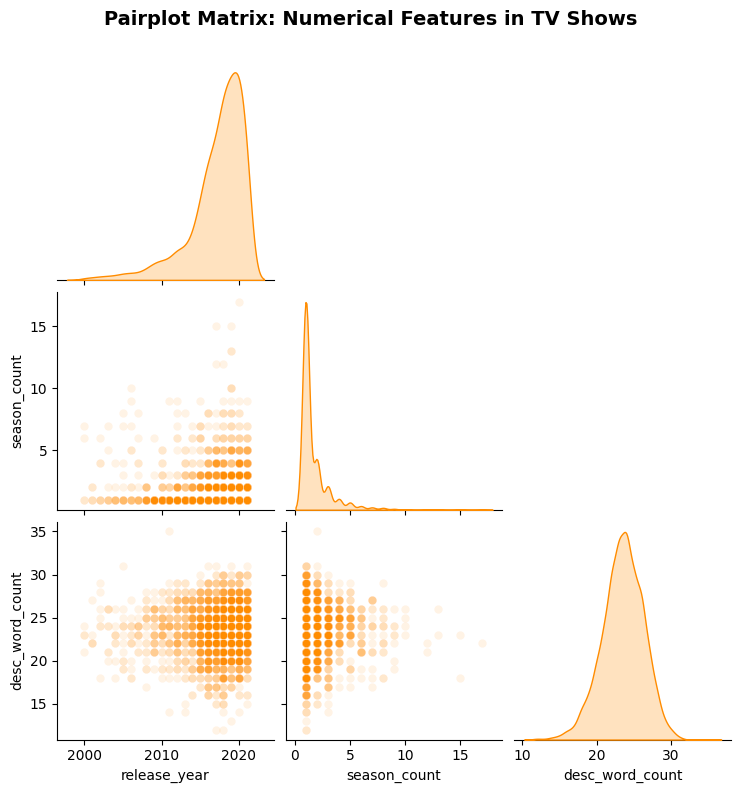

In [60]:
df_TVshows['desc_word_count'] = df_TVshows['description'].apply(lambda x: len(str(x).split()))
# 2. Filter out the historical noise
recent_tv_shows = df_TVshows[df_TVshows['release_year'] >= 2000]
# 3. Grab ONLY the numerical columns
tv_numerical_features = ['release_year', 'season_count', 'desc_word_count']
df_tv_ml_prep = recent_tv_shows[tv_numerical_features]

# 4. Generate the Pairplot Matrix
sns.pairplot(df_tv_ml_prep, 
             corner=True,       
             diag_kind='kde',   
             plot_kws={'alpha': 0.1, 'color': 'darkorange'}, # Using orange to separate it from the movie charts
             diag_kws={'fill': True, 'color': 'darkorange'})

plt.suptitle('Pairplot Matrix: Numerical Features in TV Shows', y=1.05, fontsize=14, fontweight='bold')
plt.show()

## The Final Verdict

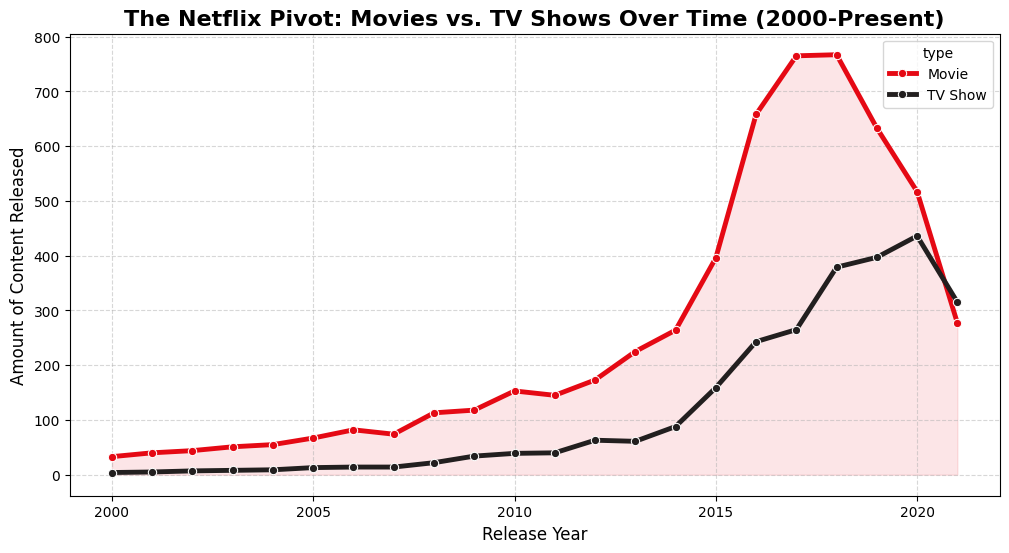

In [61]:
df_modern = df[df['release_year'] >= 2000]

# 2. Group the data by Year and Type (Movie vs. TV Show)
portfolio_trend = df_modern.groupby(['release_year', 'type']).size().reset_index(name='content_count')

# 3. Draw the unified trendline
plt.figure(figsize=(12, 6))

sns.lineplot(data=portfolio_trend, 
             x='release_year', 
             y='content_count', 
             hue='type', 
             linewidth=3.5, 
             palette=['#E50914', '#221F1F'], # Netflix Red and Dark Grey
             marker='o',
             markersize=6)

plt.title('The Netflix Pivot: Movies vs. TV Shows Over Time (2000-Present)', fontsize=16, fontweight='bold')
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Amount of Content Released', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Fill the area under the lines for a highly professional "Dashboard" look
plt.fill_between(portfolio_trend[portfolio_trend['type'] == 'Movie']['release_year'], 
                 portfolio_trend[portfolio_trend['type'] == 'Movie']['content_count'], 
                 color='#E50914', alpha=0.1)

plt.show()

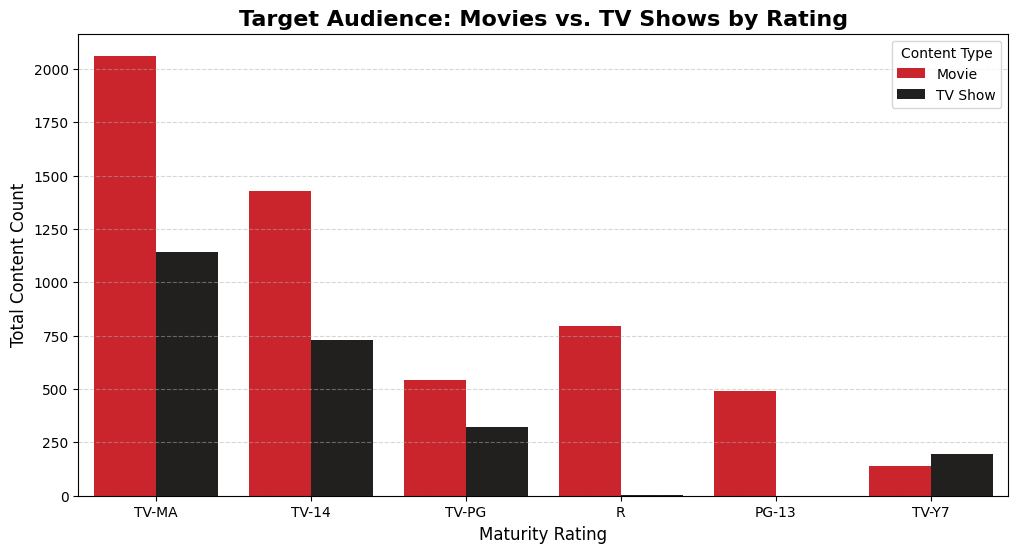

In [62]:
top_6_ratings = df['rating'].value_counts().head(6).index
df_top_ratings = df[df['rating'].isin(top_6_ratings)]

# 2. Draw the Grouped Bar Chart
plt.figure(figsize=(12, 6))

sns.countplot(data=df_top_ratings, 
              x='rating', 
              hue='type', 
              order=top_6_ratings,          # Sorts the bars from largest to smallest
              palette=['#E50914', '#221F1F']) # Netflix Red and Dark Grey

plt.title('Target Audience: Movies vs. TV Shows by Rating', fontsize=16, fontweight='bold')
plt.xlabel('Maturity Rating', fontsize=12)
plt.ylabel('Total Content Count', fontsize=12)
plt.legend(title='Content Type')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

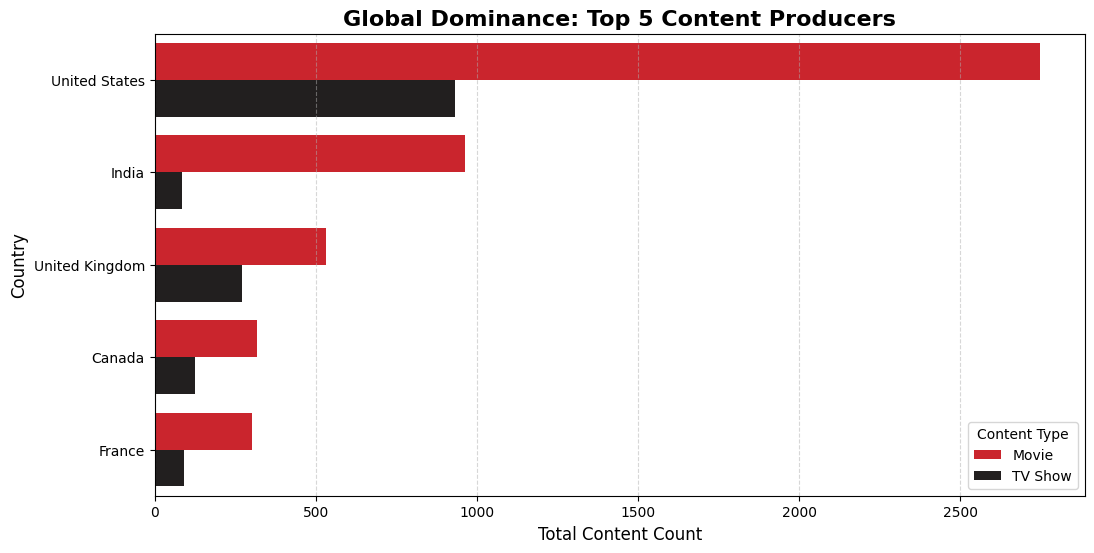

In [63]:
df_country_exploded = df.assign(country=df['country'].str.split(', ')).explode('country')

# 2. Find the Top 5 producing countries overall
top_5_countries = df_country_exploded['country'].value_counts().head(5).index
df_top_countries = df_country_exploded[df_country_exploded['country'].isin(top_5_countries)]

# 3. Draw a Horizontal Grouped Bar Chart (Horizontal is better for reading long country names)
plt.figure(figsize=(12, 6))

sns.countplot(data=df_top_countries, 
              y='country',                  # Setting this to 'y' flips the chart horizontally
              hue='type', 
              order=top_5_countries, 
              palette=['#E50914', '#221F1F'])

plt.title('Global Dominance: Top 5 Content Producers', fontsize=16, fontweight='bold')
plt.xlabel('Total Content Count', fontsize=12)
plt.ylabel('Country', fontsize=12)
plt.legend(title='Content Type')
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.show()